# Bank Campaign Targeting System - Exploratory Data Analysis

This notebook explores the model-ready version of the UCI Bank Marketing dataset for a bank campaign targeting project.

The main goal of this EDA is to understand:

1. The subscription target distribution.
2. Customer and campaign patterns related to subscription.
3. Class imbalance.
4. Variables that may be useful for modeling and business prioritization.
5. The leakage decision around `duration`.

## 1. Setup


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd()

# If the notebook is opened from the notebooks/ folder, move one level up.
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "bank_marketing_model_ready.csv"
RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "bank_marketing_uci_bank_additional_full_raw.csv"

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

print("Project root:", PROJECT_ROOT)
print("Processed data path exists:", DATA_PATH.exists())
print("Raw data path exists:", RAW_DATA_PATH.exists())

Project root: /Users/morenomusadat/Downloads/bank-campaign-targeting-system
Processed data path exists: True
Raw data path exists: True


In [2]:
df = pd.read_csv(DATA_PATH)

print("Model-ready dataset shape:", df.shape)
display(df.head())

Model-ready dataset shape: (41176, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,y_binary
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0


## 2. Basic Data Checks

In [3]:
basic_checks = {
    "rows": df.shape[0],
    "columns": df.shape[1],
    "missing_values": int(df.isna().sum().sum()),
    "duplicate_rows": int(df.duplicated().sum()),
    "duration_in_model_ready": "duration" in df.columns,
    "target_column_exists": "y" in df.columns,
    "binary_target_exists": "y_binary" in df.columns,
    "target_values": sorted(df["y"].dropna().unique().tolist()),
}

basic_checks_df = pd.DataFrame(
    [{"check": key, "value": value} for key, value in basic_checks.items()]
)

display(basic_checks_df)

,check,value
0,rows,41176
1,columns,21
2,missing_values,0
3,duplicate_rows,1772
4,duration_in_model_ready,False
5,target_column_exists,True
6,binary_target_exists,True
7,target_values,"[no, yes]"


These checks confirm that the processed dataset is ready for EDA and later modeling.

- `duration` should not exist in the model-ready dataset.
- `y_binary` should exist as the numeric version of the target.
- The target should only contain `yes` and `no`.

### Leakage Check

The `duration` feature is excluded from the model-ready dataset because it is only known after a customer has already been contacted. Since the project is about pre-call targeting, using this feature would create target leakage.

In [4]:
raw_df = pd.read_csv(RAW_DATA_PATH)

leakage_check = pd.DataFrame(
    {
        "item": [
            "duration_exists_in_raw_data",
            "duration_exists_in_model_ready_data",
            "raw_columns",
            "model_ready_columns",
        ],
        "value": [
            "duration" in raw_df.columns,
            "duration" in df.columns,
            raw_df.shape[1],
            df.shape[1],
        ],
    }
)

display(leakage_check)

,item,value
0,duration_exists_in_raw_data,True
1,duration_exists_in_model_ready_data,False
2,raw_columns,21
3,model_ready_columns,21


The raw dataset is checked only to document that `duration` originally existed.

## 3. Target Distribution and Class Imbalance

This section checks how many customers subscribed to the term deposit.

The positive class is `yes`, represented as `1` in `y_binary`.


In [5]:
target_summary = (
    df["y"]
    .value_counts()
    .rename_axis("subscription")
    .reset_index(name="count")
)
target_summary["percentage"] = (target_summary["count"] / len(df) * 100).round(2)

display(target_summary)

target_summary.to_csv(REPORTS_DIR / "eda_target_summary.csv", index=False)

,subscription,count,percentage
0,no,36537,88.73
1,yes,4639,11.27


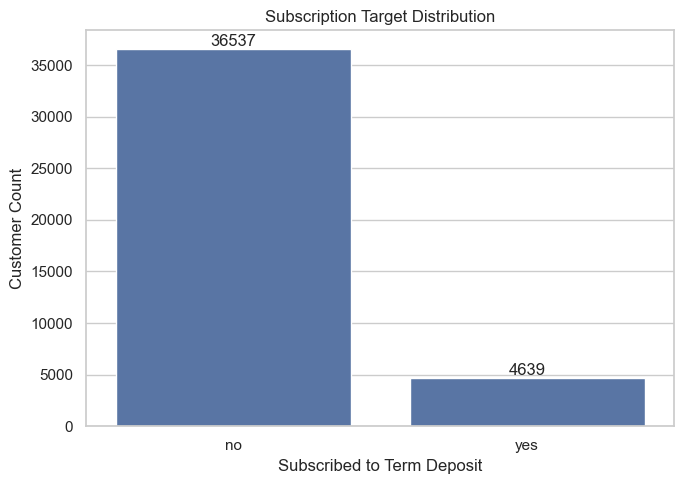

In [6]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x="y", order=["no", "yes"])
plt.title("Subscription Target Distribution")
plt.xlabel("Subscribed to Term Deposit")
plt.ylabel("Customer Count")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "target_distribution.png", dpi=150)
plt.show()

In [8]:
positive_rate = df["y_binary"].mean()
negative_rate = 1 - positive_rate

print(f"Positive class rate: {positive_rate:.4f} ({positive_rate * 100:.2f}%)")
print(f"Negative class rate: {negative_rate:.4f} ({negative_rate * 100:.2f}%)")

if positive_rate < 0.2:
    print("Observation: The dataset is imbalanced.")

Positive class rate: 0.1127 (11.27%)
Negative class rate: 0.8873 (88.73%)
Observation: The dataset is imbalanced.


## 4. Column Types

This section separates categorical and numerical variables for EDA.

The target columns `y` and `y_binary` are excluded from the feature lists.


In [9]:
target_cols = ["y", "y_binary"]

feature_cols = [col for col in df.columns if col not in target_cols]

categorical_cols = df[feature_cols].select_dtypes(include=["object"]).columns.tolist()
numerical_cols = df[feature_cols].select_dtypes(exclude=["object"]).columns.tolist()

column_type_summary = pd.DataFrame(
    {
        "type": ["categorical", "numerical"],
        "count": [len(categorical_cols), len(numerical_cols)],
        "columns": [", ".join(categorical_cols), ", ".join(numerical_cols)],
    }
)

display(column_type_summary)

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

,type,count,columns
0,categorical,10,"job, marital, education, default, housing, loa..."
1,numerical,9,"age, campaign, pdays, previous, emp.var.rate, ..."


Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Numerical columns: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


## 5. Numerical Feature Summary

The goal here is to understand the scale and distribution of numerical features.

For campaign targeting, variables such as campaign contact count, previous contacts, and economic indicators may be useful, but their actual value must be tested later through modeling.


In [10]:
numerical_summary = df[numerical_cols].describe().T
numerical_summary["missing_count"] = df[numerical_cols].isna().sum()
numerical_summary["missing_rate"] = df[numerical_cols].isna().mean()
display(numerical_summary)

numerical_summary.to_csv(REPORTS_DIR / "eda_numerical_summary.csv")

,count,mean,std,min,25%,50%,75%,max,missing_count,missing_rate
age,41176.0,40.023800,10.420680,17.000,32.000,38.000,47.000,98.000,0,0.0
campaign,41176.0,2.567879,2.770318,1.000,1.000,2.000,3.000,56.000,0,0.0
pdays,41176.0,962.464810,186.937102,0.000,999.000,999.000,999.000,999.000,0,0.0
previous,41176.0,0.173013,0.494964,0.000,0.000,0.000,0.000,7.000,0,0.0
emp.var.rate,41176.0,0.081922,1.570883,-3.400,-1.800,1.100,1.400,1.400,0,0.0
cons.price.idx,41176.0,93.575720,0.578839,92.201,93.075,93.749,93.994,94.767,0,0.0
cons.conf.idx,41176.0,-40.502863,4.627860,-50.800,-42.700,-41.800,-36.400,-26.900,0,0.0
euribor3m,41176.0,3.621293,1.734437,0.634,1.344,4.857,4.961,5.045,0,0.0
nr.employed,41176.0,5167.034870,72.251364,4963.600,5099.100,5191.000,5228.100,5228.100,0,0.0


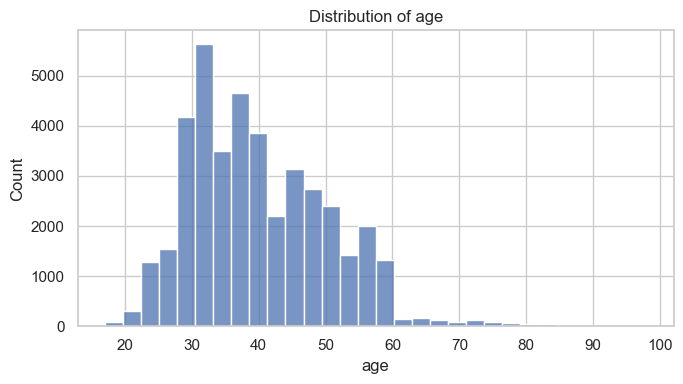

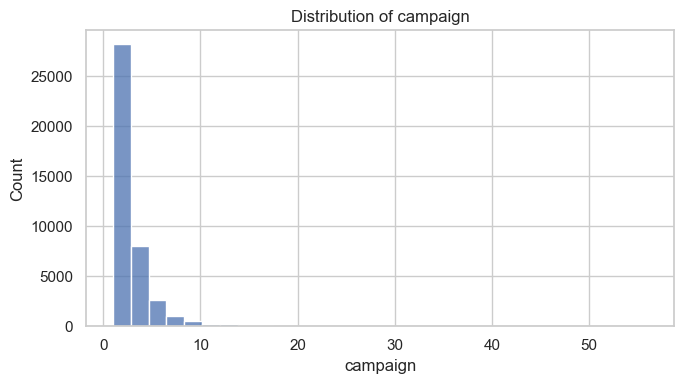

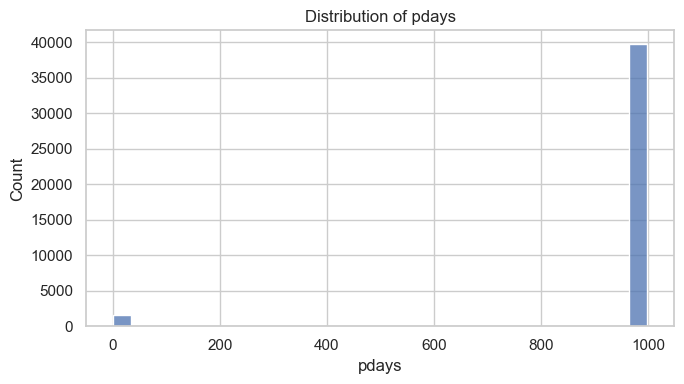

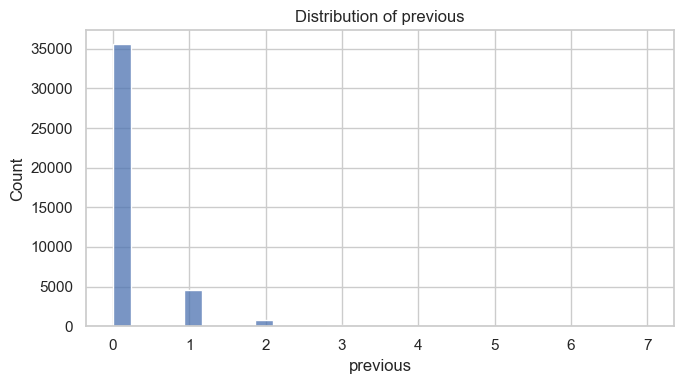

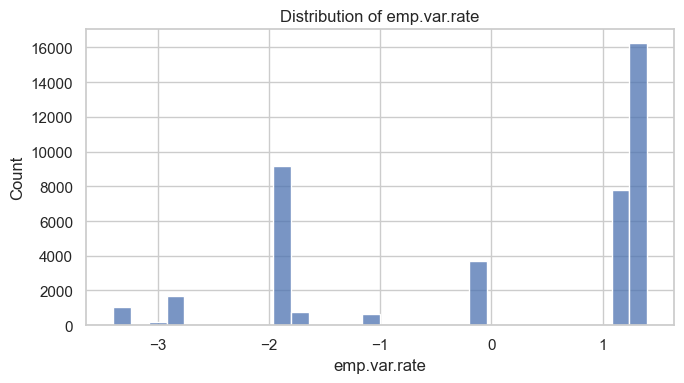

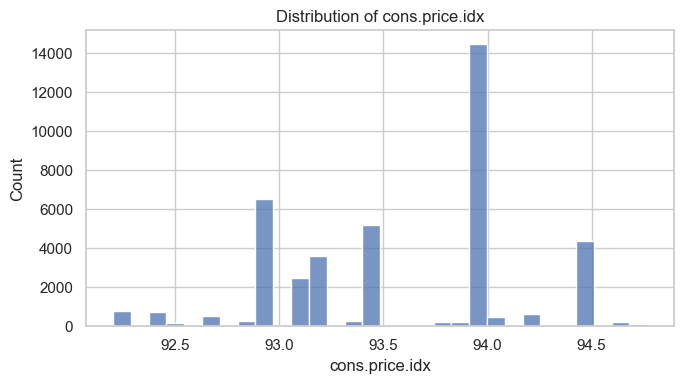

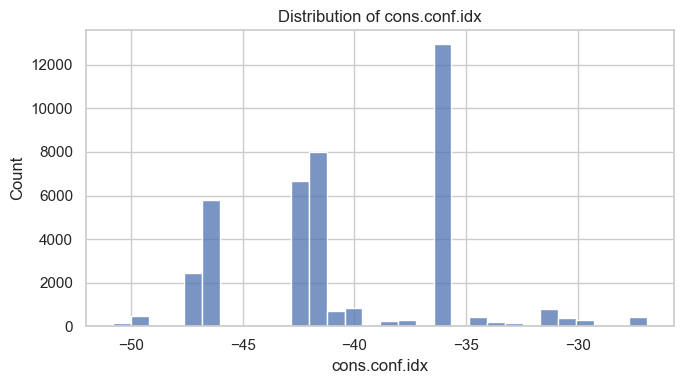

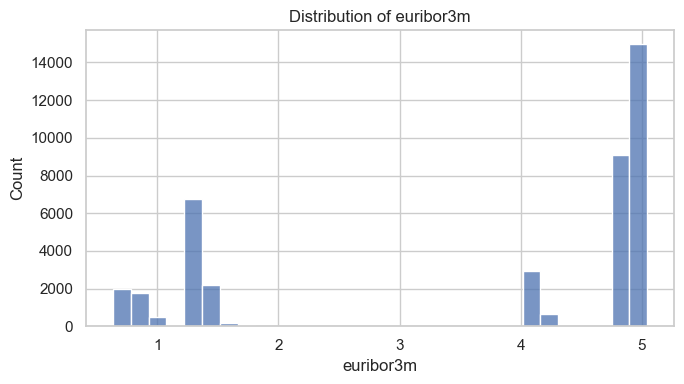

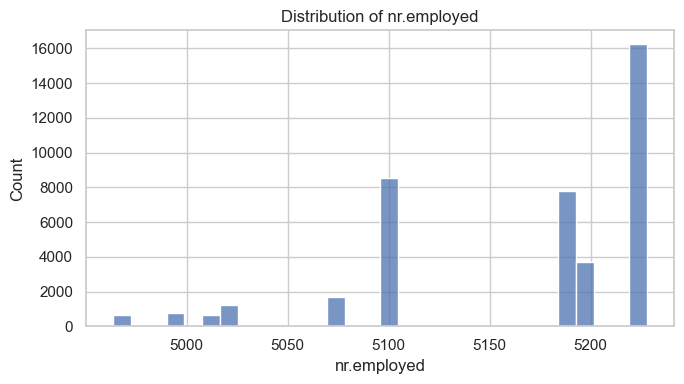

In [11]:
for col in numerical_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=df, x=col, bins=30, kde=False)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"dist_{col}.png", dpi=150)
    plt.show()

## 6. Categorical Feature Summary

This section checks the number of categories in each categorical feature.

In [12]:
categorical_summary = []

for col in categorical_cols:
    categorical_summary.append(
        {
            "column": col,
            "unique_count": df[col].nunique(dropna=False),
            "top_value": df[col].value_counts(dropna=False).index[0],
            "top_count": df[col].value_counts(dropna=False).iloc[0],
            "top_percentage": round(df[col].value_counts(dropna=False).iloc[0] / len(df) * 100, 2),
        }
    )

categorical_summary = pd.DataFrame(categorical_summary)
display(categorical_summary)

categorical_summary.to_csv(REPORTS_DIR / "eda_categorical_summary.csv", index=False)

,column,unique_count,top_value,top_count,top_percentage
0,job,12,admin.,10419,25.30
1,marital,4,married,24921,60.52
2,education,8,university.degree,12164,29.54
3,default,3,no,32577,79.12
4,housing,3,yes,21571,52.39
5,loan,3,no,33938,82.42
6,contact,2,cellular,26135,63.47
7,month,10,may,13767,33.43
8,day_of_week,5,thu,8618,20.93
9,poutcome,3,nonexistent,35551,86.34


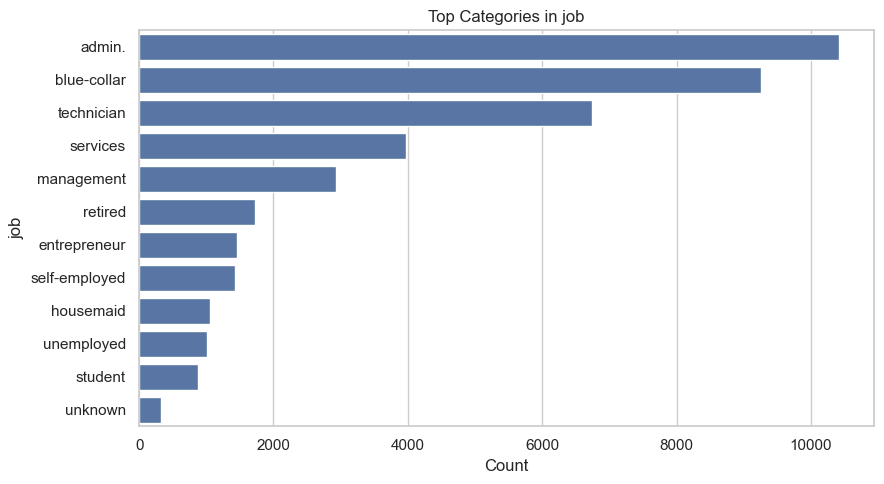

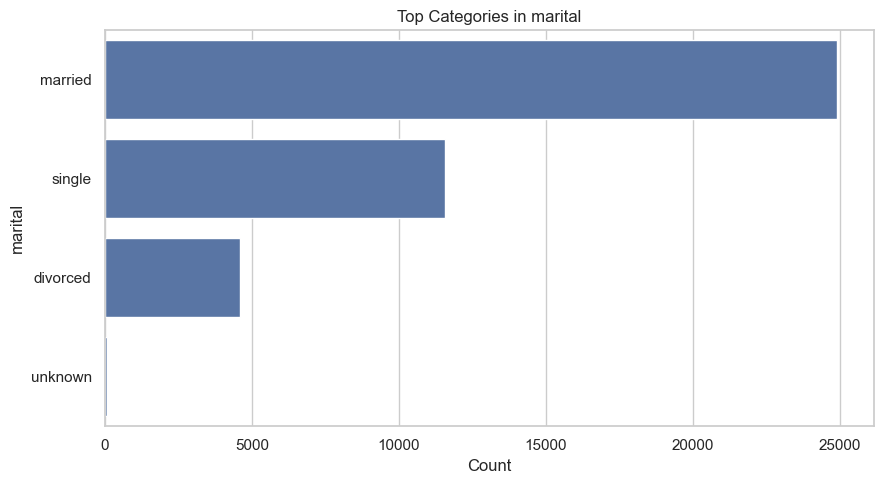

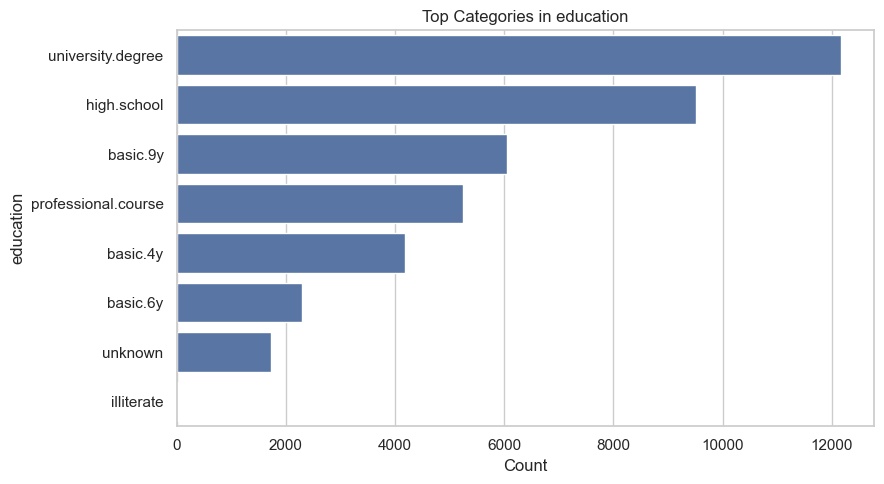

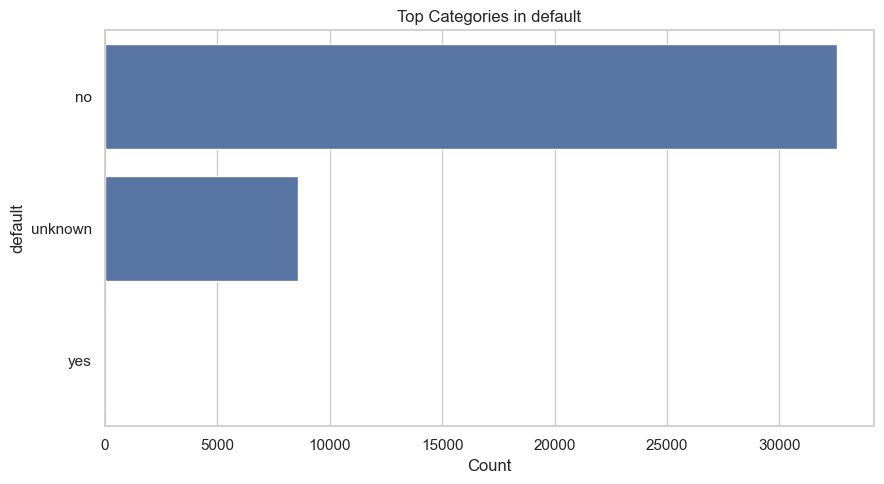

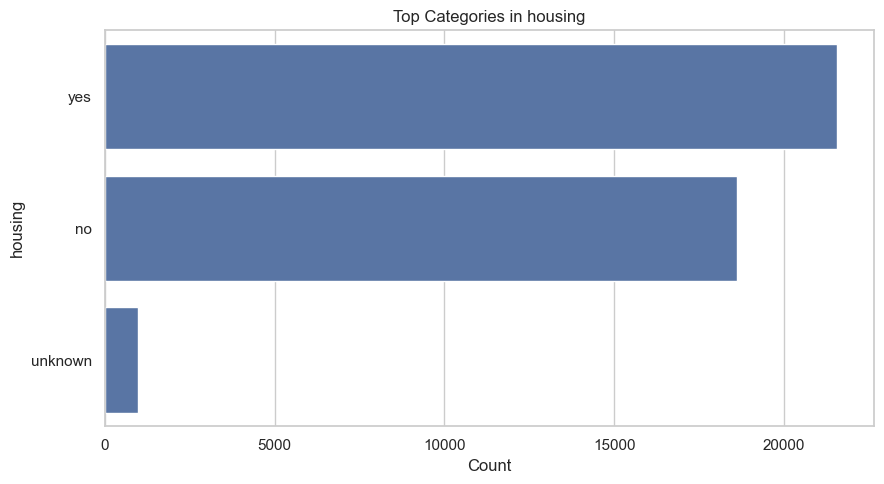

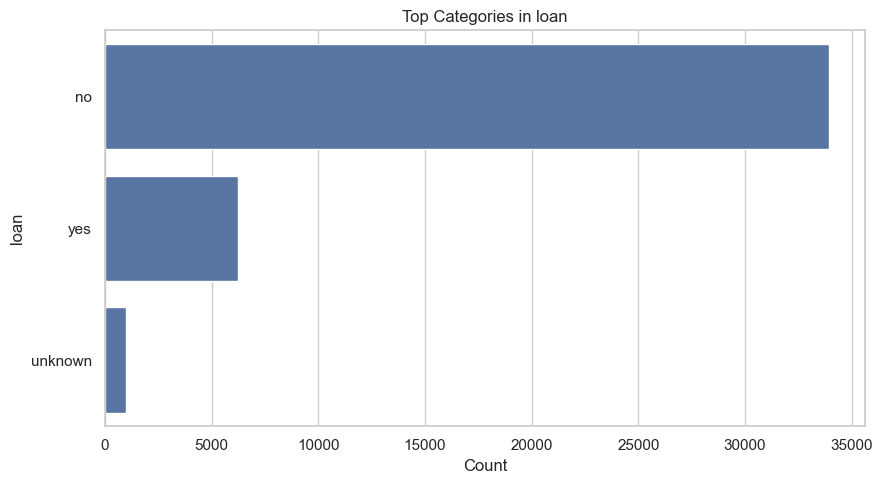

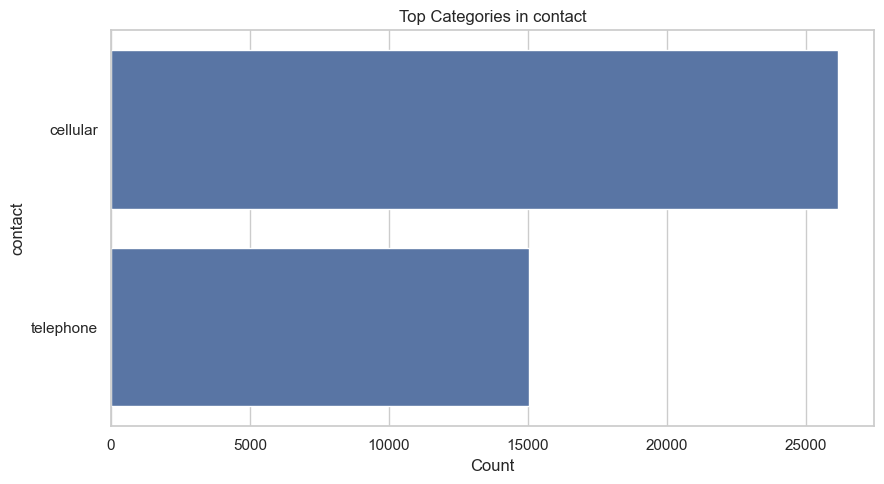

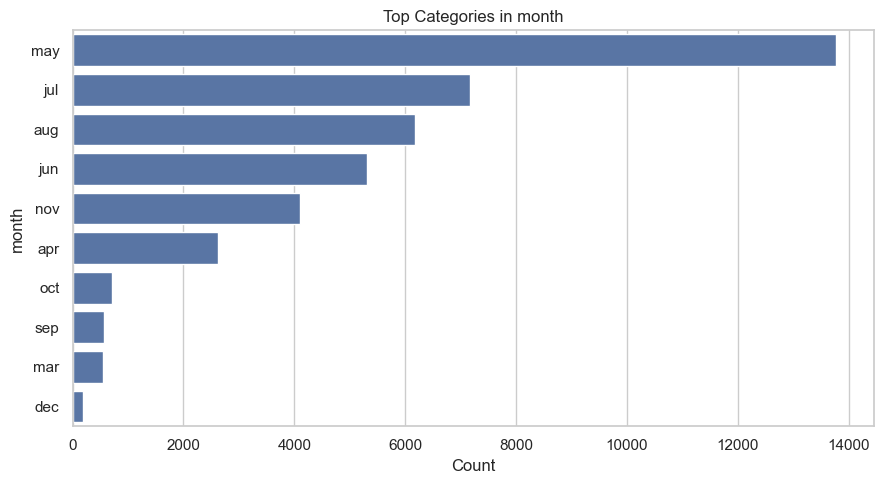

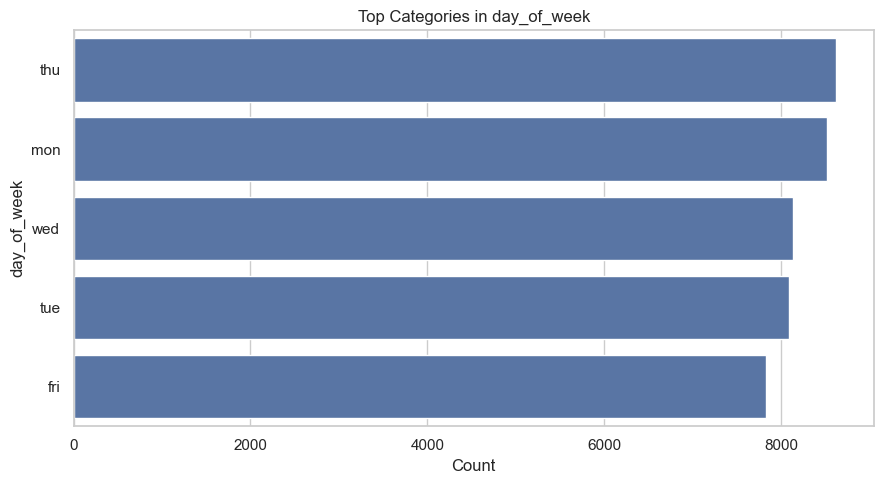

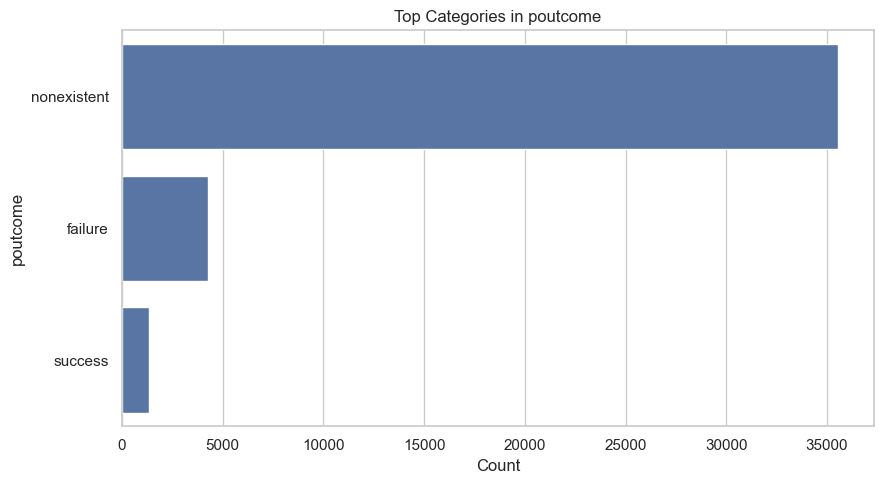

In [13]:
for col in categorical_cols:
    value_counts = df[col].value_counts().head(15).reset_index()
    value_counts.columns = [col, "count"]

    plt.figure(figsize=(9, 5))
    sns.barplot(data=value_counts, y=col, x="count")
    plt.title(f"Top Categories in {col}")
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"top_categories_{col}.png", dpi=150)
    plt.show()

## 7. Conversion Rate by Segment

This section compares subscription rate across selected features with the goal being not to claim causality. The goal is to identify patterns that may be useful for modeling and business understanding.


In [14]:
def conversion_by_category(data: pd.DataFrame, column: str, min_count: int = 50) -> pd.DataFrame:
    summary = (
        data.groupby(column)
        .agg(
            customer_count=("y_binary", "size"),
            subscription_count=("y_binary", "sum"),
            subscription_rate=("y_binary", "mean"),
        )
        .reset_index()
    )
    summary = summary[summary["customer_count"] >= min_count].copy()
    summary["subscription_rate"] = (summary["subscription_rate"] * 100).round(2)
    summary = summary.sort_values("subscription_rate", ascending=False)
    return summary


segment_columns = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "day_of_week",
    "poutcome",
]

segment_outputs = {}

for col in segment_columns:
    if col in df.columns:
        segment_outputs[col] = conversion_by_category(df, col)
        print(f"Conversion by {col}")
        display(segment_outputs[col].head(15))

Conversion by job


,job,customer_count,subscription_count,subscription_rate
8,student,875,275,31.43
5,retired,1718,434,25.26
10,unemployed,1014,144,14.20
0,admin.,10419,1351,12.97
4,management,2924,328,11.22
11,unknown,330,37,11.21
9,technician,6739,730,10.83
6,self-employed,1421,149,10.49
3,housemaid,1060,106,10.00
2,entrepreneur,1456,124,8.52


Conversion by marital


,marital,customer_count,subscription_count,subscription_rate
3,unknown,80,12,15.00
2,single,11564,1620,14.01
0,divorced,4611,476,10.32
1,married,24921,2531,10.16


Conversion by education


...

,month,customer_count,subscription_count,subscription_rate
5,mar,546,276,50.55
2,dec,182,89,48.90
9,sep,570,256,44.91
8,oct,717,315,43.93
0,apr,2631,539,20.49
1,aug,6176,655,10.61
4,jun,5318,559,10.51
7,nov,4100,416,10.15
3,jul,7169,648,9.04
6,may,13767,886,6.44


Conversion by day_of_week


,day_of_week,customer_count,subscription_count,subscription_rate
2,thu,8618,1044,12.11
3,tue,8086,953,11.79
4,wed,8134,949,11.67
0,fri,7826,846,10.81
1,mon,8512,847,9.95


Conversion by poutcome


,poutcome,customer_count,subscription_count,subscription_rate
2,success,1373,894,65.11
0,failure,4252,605,14.23
1,nonexistent,35551,3140,8.83


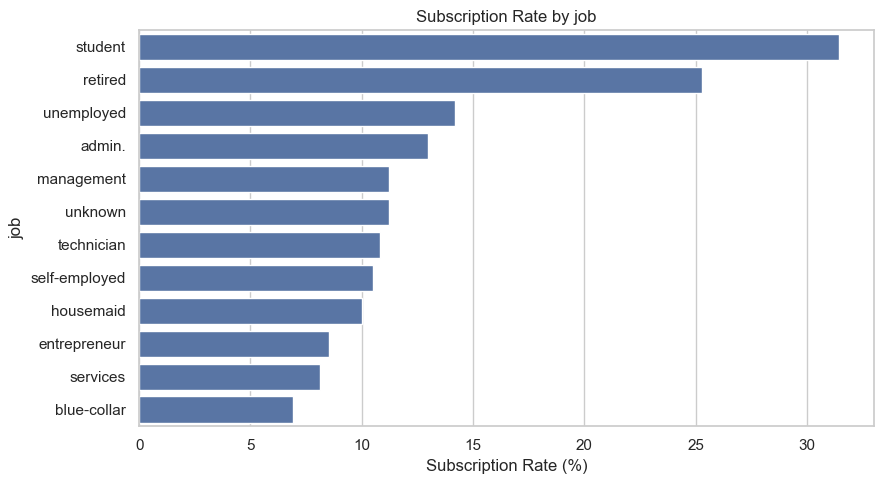

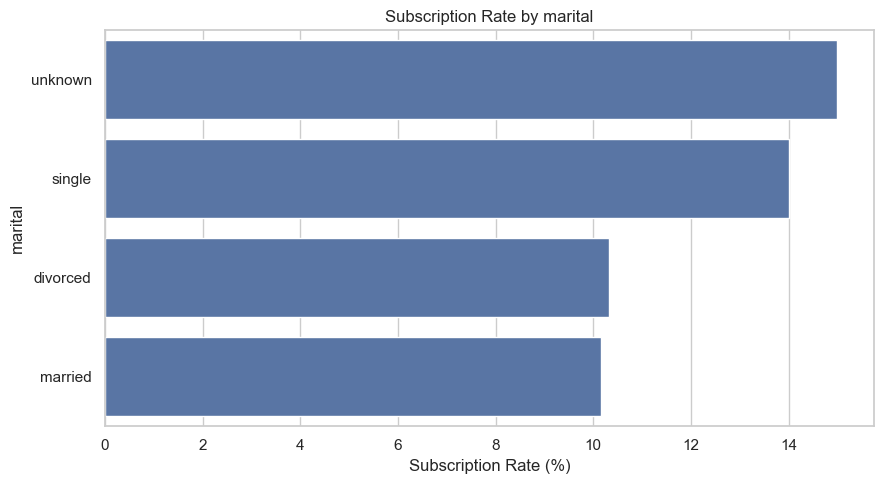

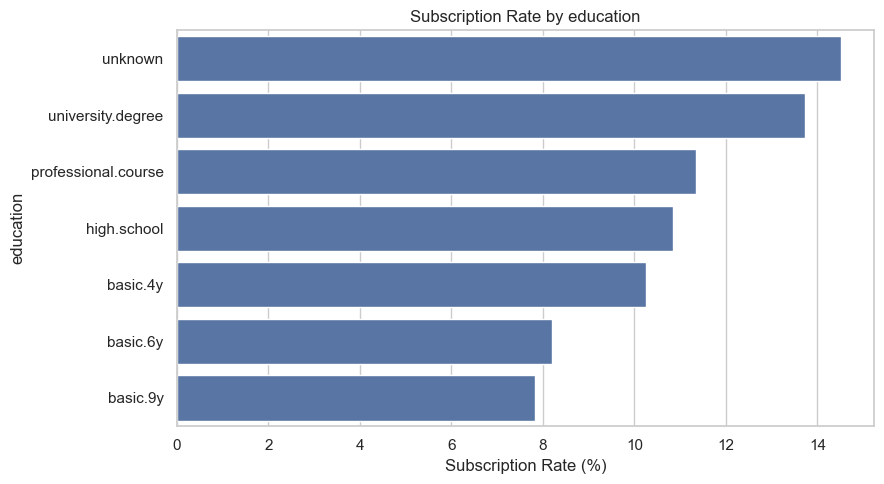

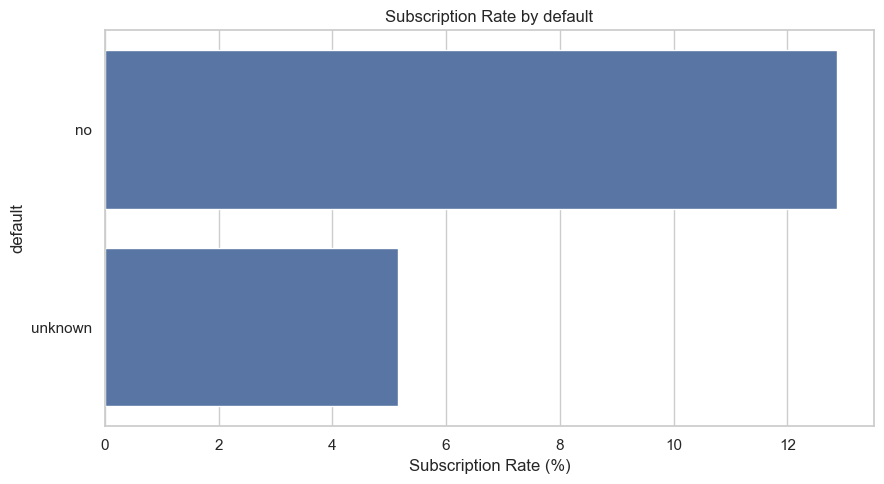

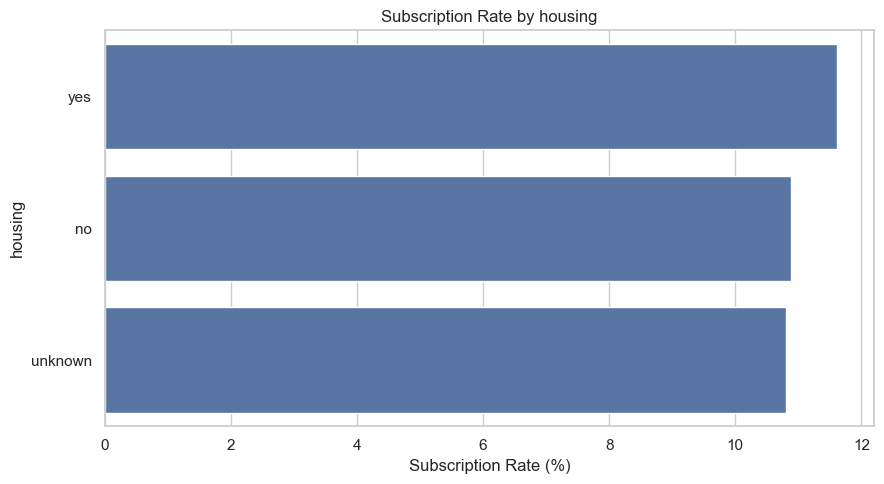

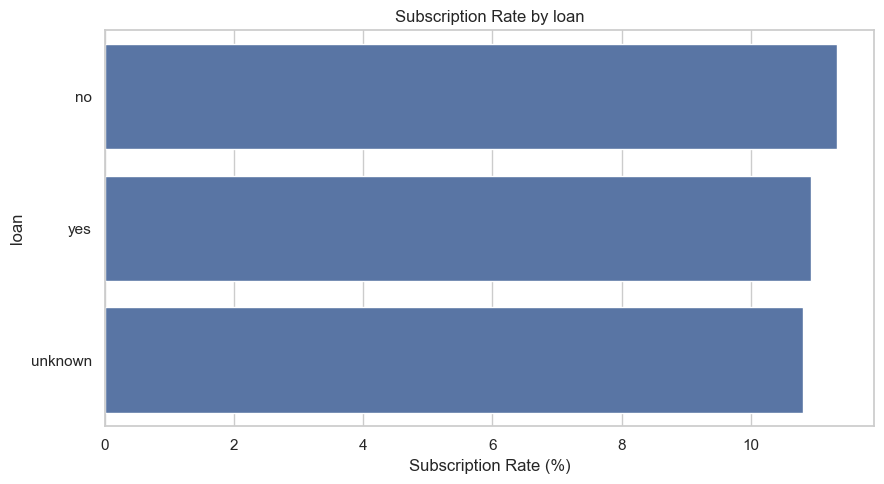

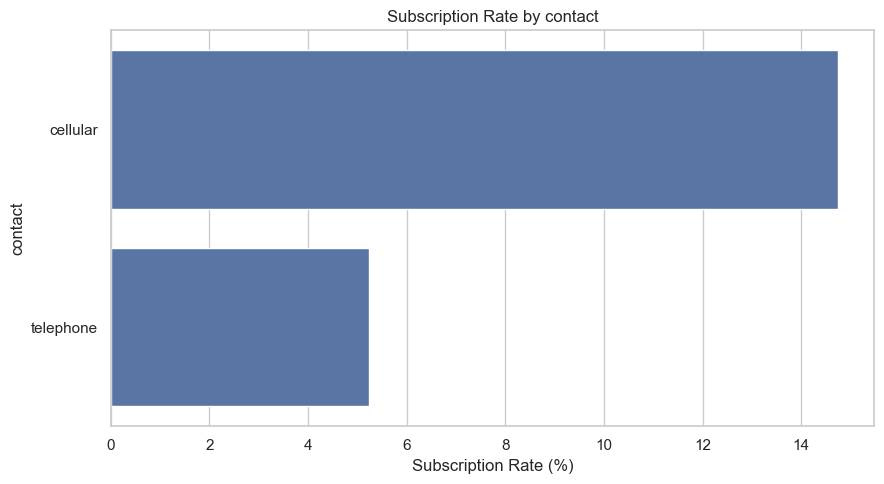

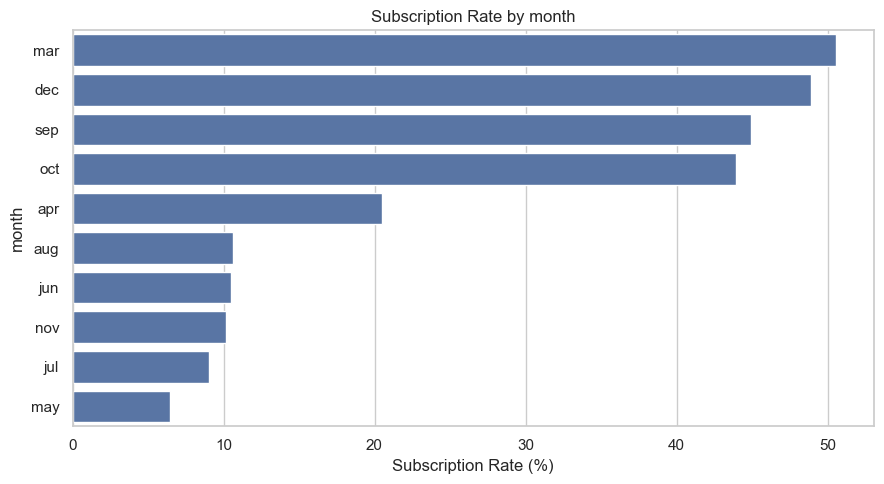

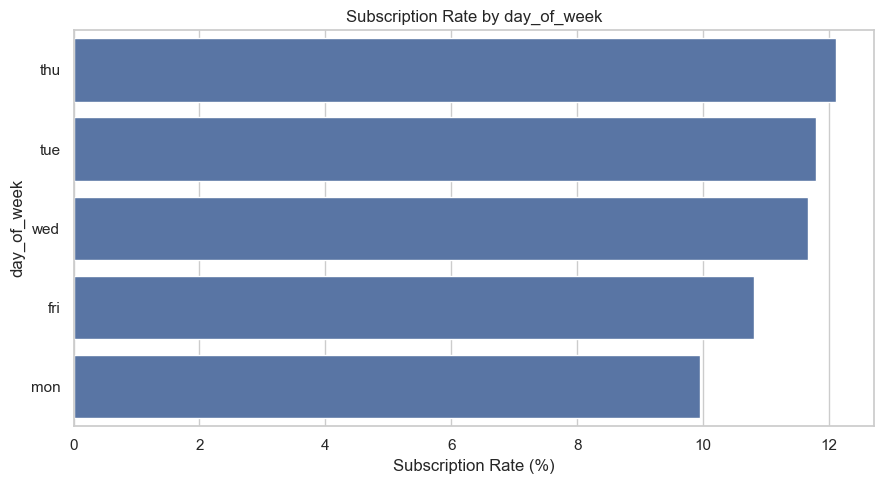

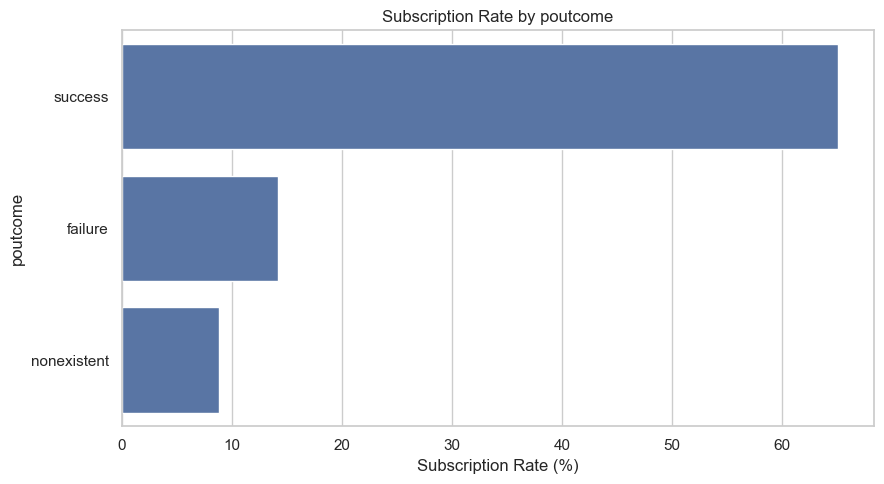

In [15]:
for col, summary in segment_outputs.items():
    plot_data = summary.sort_values("subscription_rate", ascending=False).head(15)

    plt.figure(figsize=(9, 5))
    sns.barplot(data=plot_data, y=col, x="subscription_rate")
    plt.title(f"Subscription Rate by {col}")
    plt.xlabel("Subscription Rate (%)")
    plt.ylabel(col)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"conversion_rate_by_{col}.png", dpi=150)
    plt.show()

## 8. Campaign Intensity Analysis

This section looks at campaign-related variables.

Important variables:

- `campaign`: number of contacts performed during this campaign.
- `pdays`: days since the client was last contacted from a previous campaign.
- `previous`: number of contacts performed before this campaign.
- `poutcome`: outcome of the previous marketing campaign.

In [16]:
campaign_cols = [col for col in ["campaign", "pdays", "previous", "poutcome"] if col in df.columns]

display(df[campaign_cols + ["y_binary"]].head())

,campaign,pdays,previous,poutcome,y_binary
0,1,999,0,nonexistent,0
1,1,999,0,nonexistent,0
2,1,999,0,nonexistent,0
3,1,999,0,nonexistent,0
4,1,999,0,nonexistent,0


,campaign_bin,customer_count,subscription_count,subscription_rate
0,1,17634,2299,13.04
1,2,10568,1211,11.46
2,3,5340,574,10.75
3,4-5,4249,369,8.68
4,6-10,2516,159,6.32
5,10+,869,27,3.11


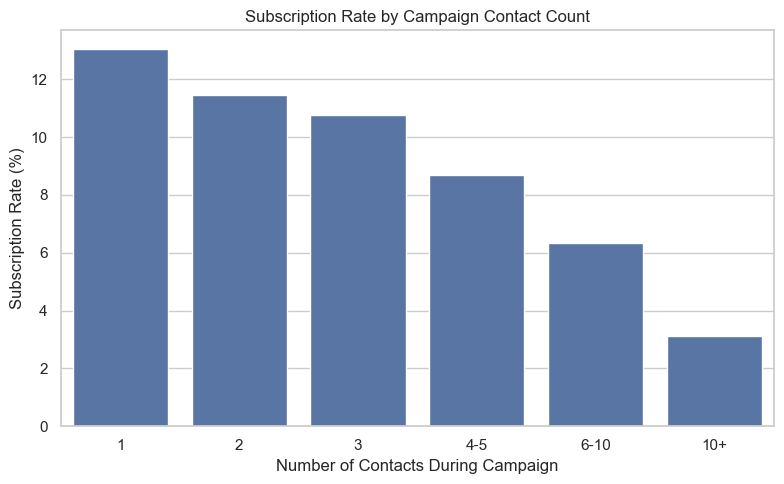

In [17]:
if "campaign" in df.columns:
    campaign_summary = (
        df.assign(campaign_bin=pd.cut(df["campaign"], bins=[0, 1, 2, 3, 5, 10, np.inf],
                                      labels=["1", "2", "3", "4-5", "6-10", "10+"]))
        .groupby("campaign_bin")
        .agg(
            customer_count=("y_binary", "size"),
            subscription_count=("y_binary", "sum"),
            subscription_rate=("y_binary", "mean"),
        )
        .reset_index()
    )
    campaign_summary["subscription_rate"] = (campaign_summary["subscription_rate"] * 100).round(2)
    display(campaign_summary)

    plt.figure(figsize=(8, 5))
    sns.barplot(data=campaign_summary, x="campaign_bin", y="subscription_rate")
    plt.title("Subscription Rate by Campaign Contact Count")
    plt.xlabel("Number of Contacts During Campaign")
    plt.ylabel("Subscription Rate (%)")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "subscription_rate_by_campaign_count.png", dpi=150)
    plt.show()

In this dataset, customers requiring more campaign contacts tended to have lower subscription rates.

## 9. Economic Context Variables

The `bank-additional-full.csv` file includes economic context variables such as employment variation rate, consumer price index, consumer confidence index, Euribor 3-month rate, and number of employees.

These variables are useful because customer decisions may be related to the broader economic environment and for the sake of this project, I will be treating them as predictive features, not causal explanations.


,count,mean,std,min,25%,50%,75%,max
emp.var.rate,41176.0,0.081922,1.570883,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41176.0,93.575720,0.578839,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41176.0,-40.502863,4.627860,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41176.0,3.621293,1.734437,0.634,1.344,4.857,4.961,5.045
nr.employed,41176.0,5167.034870,72.251364,4963.600,5099.100,5191.000,5228.100,5228.100
y_binary,41176.0,0.112663,0.316184,0.000,0.000,0.000,0.000,1.000


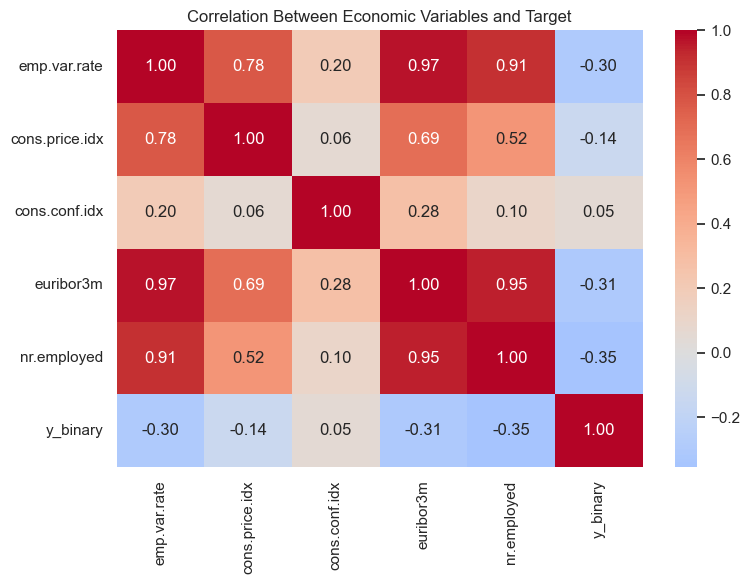

In [18]:
economic_cols = [col for col in ["emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"] if col in df.columns]

if economic_cols:
    display(df[economic_cols + ["y_binary"]].describe().T)

    corr_data = df[economic_cols + ["y_binary"]].corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_data, annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title("Correlation Between Economic Variables and Target")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "economic_variables_correlation.png", dpi=150)
    plt.show()
else:
    print("No economic columns found.")

## 10. Simple Feature Relationship Checks

This section creates a basic correlation view for numerical variables. For categorical variables, model-based feature importance will be more useful later after encoding.


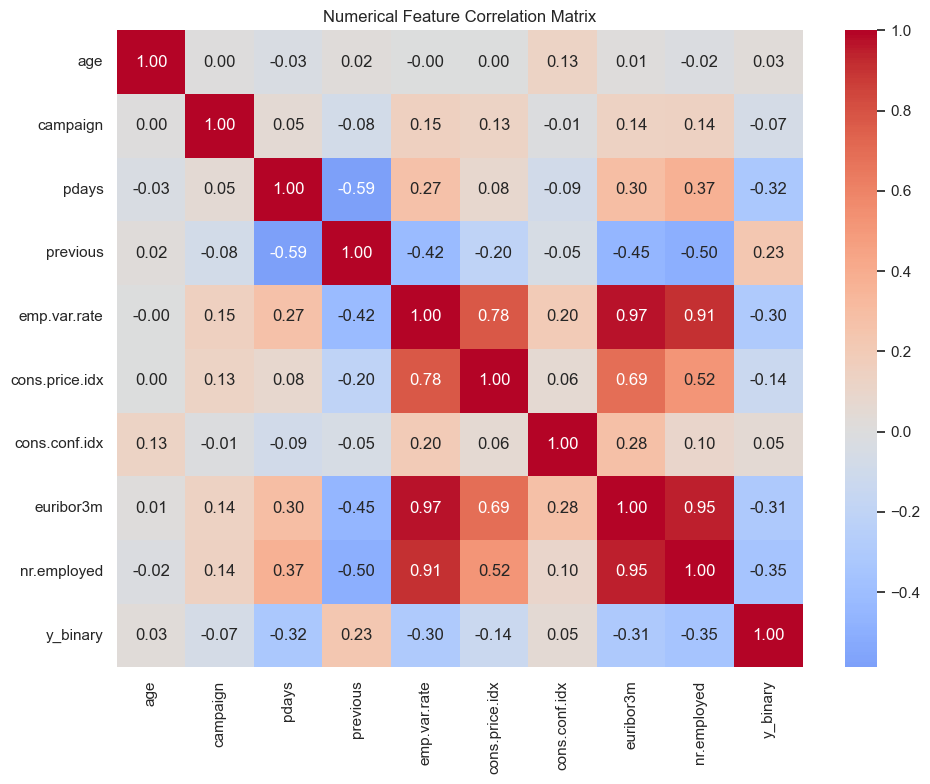

In [19]:
corr_cols = numerical_cols + ["y_binary"]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Numerical Feature Correlation Matrix")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "numerical_correlation_matrix.png", dpi=150)
plt.show()

## 11. EDA Business Insight Summary

This section exist to generate a simple CSV of EDA insights in case I need to document certain stuff.

In [20]:
insights = []

insights.append(
    {
        "topic": "Target distribution",
        "finding": f"The positive class rate is {positive_rate * 100:.2f}%, so the dataset is imbalanced.",
        "project_use": "Use metrics beyond accuracy, such as PR-AUC, recall, precision, F1, and threshold simulation.",
    }
)

insights.append(
    {
        "topic": "Leakage handling",
        "finding": "The duration column exists in the raw data but is excluded from the model-ready dataset.",
        "project_use": "This keeps the project aligned with a pre-call targeting use case.",
    }
)

for col, summary in segment_outputs.items():
    if not summary.empty:
        top_row = summary.iloc[0]
        insights.append(
            {
                "topic": f"Segment pattern: {col}",
                "finding": (
                    f"The highest observed subscription rate for {col} is "
                    f"{top_row[col]} at {top_row['subscription_rate']}% "
                    f"among categories with at least 50 customers."
                ),
                "project_use": "Use as exploratory context. This does not prove causality.",
            }
        )

eda_insights = pd.DataFrame(insights)
display(eda_insights)

eda_insights.to_csv(REPORTS_DIR / "eda_business_insights.csv", index=False)

,topic,finding,project_use
0,Target distribution,"The positive class rate is 11.27%, so the data...","Use metrics beyond accuracy, such as PR-AUC, r..."
1,Leakage handling,The duration column exists in the raw data but...,This keeps the project aligned with a pre-call...
2,Segment pattern: job,The highest observed subscription rate for job...,Use as exploratory context. This does not prov...
3,Segment pattern: marital,The highest observed subscription rate for mar...,Use as exploratory context. This does not prov...
4,Segment pattern: education,The highest observed subscription rate for edu...,Use as exploratory context. This does not prov...
5,Segment pattern: default,The highest observed subscription rate for def...,Use as exploratory context. This does not prov...
6,Segment pattern: housing,The highest observed subscription rate for hou...,Use as exploratory context. This does not prov...
7,Segment pattern: loan,The highest observed subscription rate for loa...,Use as exploratory context. This does not prov...
8,Segment pattern: contact,The highest observed subscription rate for con...,Use as exploratory context. This does not prov...
9,Segment pattern: month,The highest observed subscription rate for mon...,Use as exploratory context. This does not prov...


*To Fix*

There was 1,772 duplicated rows found after the leakage removal ('duration'). This will need to be addressbefore modeling.